# Stochastic simulation model
Following is the code for stochastic simulations that predicted various patterns, including the distribution pattern, accumulation per branch, somatic phylogeny, and inter-branch SNVs.

##### Packages information used in this code:  
numpy==2.0.1  
scipy==1.15.3  
seaborn==0.13.2  
pandas==2.2.3  
matplotlib==3.10.0 

In [1]:
%matplotlib inline
import math
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import random
import copy
import numpy as np

In [2]:
from scipy import stats
from scipy.stats import norm

import itertools

In [3]:
import csv
import pandas as pd

### Elongation

In [4]:
# Func in Elongation

def mutInStemCells(num_stem, t, mu_0, Genom, st_d):
      
    """　Func for Elognation from a seed
    Args:
        num_stem  (int): Num of stem cells in a meristem
        t         (int): Num of cell divisions in elongation
        mu_0    (float): Mut rate per cell per division
        Genom     (int): Genome size
        st_d      (int): Para for somatic drift (alpha - gamma)
        
    Return:
        t_cells   (list): History of mutation accumulation during the elongation
    """
    
    t_cells = [] # list for history of stemcells in meristem
    stem_cells = [[i,[]] for i in range(num_stem)] # [(ID number）,[list of mutations]]

    t_cells = copy.deepcopy(stem_cells)
    
    for k in range(t): # one cycle of division
        
        # one daughter cells
        ccells = [[0,0] for i in range(num_stem)]
        for i in range(num_stem):
            m = random.random()
            
            if m > mu_0: # non mutaion
                ccells[i] = [stem_cells[i][0], stem_cells[i][1]]
            else: # mutation
                lst = copy.deepcopy(stem_cells[i][1])
                lst.append(random.randint(1,Genom)) # site of Genom in which mut occure
                ccells[i] = [stem_cells[i][0], lst]
    
        # the other daughter cells
        ccells2 = [[0,0] for i in range(num_stem)] 
        for i in range(num_stem):
            m = random.random()
            if m > mu_0: # non mutaion
                ccells2[i] = [stem_cells[i][0], stem_cells[i][1]]
            else: # mutaion
                lst = copy.deepcopy(stem_cells[i][1])
                lst.append(random.randint(1,Genom)) # site of Genom in which mut occure
                ccells2[i] = [stem_cells[i][0], lst]
        
        # step1 + step2: choose cells of next meristem
        stem_cells = random.sample(ccells + random.sample(ccells2, st_d), num_stem) # step1: random.sample(ccells2, st_d) by gammma(num_stem - st_d)
        
        t_cells = t_cells + copy.deepcopy(stem_cells)
        
    return t_cells

def mutInBrStemCells(num_stem, stem_cells, t, mu_0, Genom, st_d): 
      
    """　Func for Elognation from a meristem
    Args:
        num_stem  (int): Num of stem cells in a meristem
        t         (int): Num of cell divisions in elongation
        mu_0    (float): Mut rate per cell per division
        Genom     (int): Genome size
        st_d      (int): Para for somatic drift (alpha - gamma)
        
    Return:
        t_cells   (list): History of mutation accumulation during the elongation
    """
    
    t_cells = copy.deepcopy(stem_cells)
    cells = copy.deepcopy(stem_cells) # to prevent reference of stemCells in for_loop

    ccells = [[0,0] for i in range(num_stem)]
    ccells2 = [[0,0] for i in range(num_stem)]
    
    for k in range(t): # one cycle of div
        
        # one daughter cells
        for i in range(num_stem):
            m = random.random()
            
            if m > mu_0: # non mutaion
                ccells[i] = [cells[i][0], cells[i][1]]
            else: # mutation
                lst = copy.deepcopy(cells[i][1])
                lst.append(random.randint(1,Genom)) # site of Genom in which mut occure
                ccells[i] = [cells[i][0], lst]
    
        # the other daughter cells
        for i in range(num_stem):
            m = random.random()
            
            if m > mu_0: # non mutaion
                ccells2[i] = [cells[i][0], cells[i][1]]
            else: # mutation
                lst = copy.deepcopy(cells[i][1])
                lst.append(random.randint(1,Genom)) # site of Genom in which mut occure
                ccells2[i] = [cells[i][0], lst]
        
        # step1 + step2: choose cells of next meristem
        cells = random.sample(ccells + random.sample(ccells2, st_d), num_stem) # step1: random.sample(ccells2, st_d) by gammma(num_stem - st_d)
        
        t_cells =t_cells + copy.deepcopy(cells)
        
    return t_cells

### Branching

In [5]:
# Wrapped Normal Distribution for sampling weights in branching

# for small sigma
def WNdist_f(x_value, mu_value, sig_value, n_value): # x, mean, var, 
    
    f_func = 1/(sig_value*math.sqrt(2*math.pi))*np.sum([math.exp(-(x_value + 2*math.pi*k - mu_value)**2/(2*sig_value**2)) for k in range(-n_value,n_value+1)]) #norm.pdf(x, loc, scale)
    
    return f_func

# for large sigma
def WNdist_g(x_value, mu_value, sig_value, n_value): # x, mean, var, 
    
    g_func = 1/(2*math.pi)*(1 + 2*np.sum([math.exp(-1/2*sig_value**2)**(k**2)*math.cos(k*(x_value-mu_value)) for k in range(1,n_value+1)])) #norm.pdf(x, loc, scale)
    
    return g_func


def WNdist(x_value, mu_value, sig_value):
    
    n_value = 5

    if sig_value < 3: # for small sigma
        dist_func = WNdist_f(x_value, mu_value, sig_value, n_value)
        
    elif sig_value >= 3: # for large sigma
        dist_func = WNdist_g(x_value, mu_value, sig_value, n_value)
        
    return dist_func


def weightList(num_stem, num_div, bias_d):
    
    """　Func for weight list in Branching
    Args:
        num_stem  (int): Num of stem cells in a meristem
        num_div   (int): Num of cell divisions in branching
        bias_d  (float): Degree of bias in branching (sigma of WN distribution)
        
    Return:
        w_list/np.sum(w_list) (ndarray): Weight list for sampling in branching
    """
    
    cell_dt = 2*math.pi/(num_stem*(2**num_div)) # distance between cells
    mean_num = random.uniform(0,2*math.pi) # center of dist
    
    w_list = np.array([WNdist(i*cell_dt, mean_num, bias_d) for i in range(num_stem*(2**num_div))])
        
    return w_list/np.sum(w_list)

In [6]:
#Sampling of stem cells in Branching

def sample(stem_cells, num_stem, num_div, mu_0, Genom, bias_d):
    
    """　Func for sampling in Branching
    Args:
        stem_cells (list): List of a meristem
        num_stem    (int): Num of stem cells in a meristem
        num_div     (int): Num of cell divisions in branching
        mu_0      (float): Mut rate per cell per division
        Genom       (int): Genome size
        bias_d    (float): Degree of bias in branching (sigma of WN distribution)
        
    Return:
        sample (list): Sampled cells for axillary meristem
    """

    w_list = weightList(num_stem, num_div, bias_d)
    cells = copy.deepcopy(stem_cells[-num_stem:])

    for k in range(0,num_div):

        ccells = [[0,0] for i in range(len(cells))]
        ccells2 = [[0,0] for i in range(len(cells))]

        # one daughter cells
        for i in range(len(cells)):
            m = random.random()
            if m > mu_0: # non mutaion
                ccells[i] = [copy.deepcopy(cells[i][0]), copy.deepcopy(cells[i][1])]
            else: # mutation
                lst = ''
                lst = copy.deepcopy(cells[i][1])
                lst.append(random.randint(1,Genom)) # site of Genom in which mut occure
                ccells[i] = [copy.deepcopy(cells[i][0]), lst]

        # the other daughter cells
        for i in range(len(cells)):
            m = random.random()
            if m > mu_0: # non mutaion
                ccells2[i] = [copy.deepcopy(cells[i][0]), copy.deepcopy(cells[i][1])]
            else: # mutaion
                lst = copy.deepcopy(cells[i][1])
                lst.append(random.randint(1,Genom)) # site of Genom in which mut occure
                ccells2[i] = [copy.deepcopy(cells[i][0]), lst]

        lst2 = [] # list for daughter cells
        for p,q in zip(ccells,ccells2):
            lst2.append(p)
            lst2.append(q)

        cells = copy.deepcopy(lst2) # daughter cells arranged in genealogical order.

        #print(cells) #check

    sample_num = np.random.choice([i for i in range(len(cells))], size=num_stem, replace=False, p=w_list) # sampling of cells for axillary meristem
    sample = [cells[i] for i in sample_num]

    return sample

### Mutation matrix

In [7]:
# detection of mutated site of whole meristems of tree
def pickUpMut(allmutList):
    mutList = []
    for i in allmutList:
        for j in i[1]:
            mutList.append(j)
            
    re_allmutList = list(set(mutList)) # eliminate overlapping of mutation
    re_allmutList.sort()
    
    return re_allmutList

# making mutation matrix from history of meristems
def makeMutMatrix(stem_cells, mutList, num_stem): # List_of_meristems、list_of_all_mutated_site、Num_of_stemcells
    
    """　Func for sampling in Branching
    Args:
        stem_cells (list): List of a meristem
        mutList    (list): List of all mutated sites
        num_stem    (int): Num of stem cells in a meristem
        
    Return:
        sample (list): Sampled cells for axillary meristem
    Note:
        return is the vector of mutated states in the meristem (its length is given in mutated sites), 
        not the mutated matrix itself.
    """
    
    mutMatrix = [[] for i in range(len(stem_cells))] # Mutation matrix
    for i,j in enumerate(stem_cells):
        for k in mutList:
            if k in j[1]:
                mutMatrix[i].append(1)
            else:
                mutMatrix[i].append(0)
    # check
    for i,j in zip(stem_cells, mutMatrix):
        if len(i[1]) != sum(j):
            print("mutation occured at the same site")
            break
    
    # sum into meristems
    np_mer_mutMatrix = np.array([0 for i in range(int(len(stem_cells)/num_stem))])
    for i in range(int(len(mutMatrix)/num_stem)): # int(len(mutMatrix)/num_stem) = number of history of merstems
        
        mer_mutVector = np.zeros(len(mutList),dtype = int)
        for j in range(num_stem):
            arraylist = np.array(mutMatrix[i*num_stem +j])
            mer_mutVector = mer_mutVector + arraylist
        
        if i == 0:
            np_mer_mutMatrix = mer_mutVector
        else:
            np_mer_mutMatrix = np.vstack((np_mer_mutMatrix, mer_mutVector))
            
    return np_mer_mutMatrix

### for saving the data in .npy

In [9]:
#_for saving the data

#for saving chage the shape of list
def add_None_func(ori_List):
    max_length = max([len(i[0]) for i in ori_List]) #scaling of maximum length
    none_List = np.array([[None] for _ in range(len(ori_List[0]))]) #len(ori_List[0]): len(copy_List) due to the type of data
    
    pre_List = []
    #count = 0 #check
    for j_ in ori_List: #loop by NumTime
        #count += 1 #check
        copy_List = copy.deepcopy(j_)
        
        while len(copy_List[0]) < max_length: #len(i_[0]): number of mutations
            copy_List = np.hstack((copy_List ,none_List))
           
        pre_List.append(copy.deepcopy(copy_List))
        #print(count)#check
    
    return pre_List

#for Refrost data
def non_None(ori_List):
    non_matrix = []
    for i in ori_List:
        pre_matrix = []
        for j in i:
            pre_matrix.append([k for k in j if k is not None])
        non_matrix.append(np.array(copy.deepcopy(pre_matrix)))

    return non_matrix

In [9]:
#null regression
def reg1dim(x, y):
    a = np.dot(x, y)/ (x ** 2).sum()
    return a

In [11]:
ind = 'S1' # ID of individual

# parameters
paraL = [None, 
         int(4.4291e+01), 6.8651e-09, 3.4863e-09, 1.3752e-09, 1.3273e-09, 2.3872e+01, 4.0] # NumStem, µ_s1, µ_s2, µ_f1, µ_f2, cell_div, model

NumStem = paraL[1]
div = paraL[6]

# mutation rate per cell division
if ind == 'S1':
    µ = paraL[2]/div *388801756
elif ind == 'S2':
    µ = paraL[3]/div *320739335
elif ind == 'F1':
    µ = paraL[4]/div *323729573
elif ind == 'F2':
    µ = paraL[5]/div *263488812

# dynamics
if paraL[-1] == 1: # stru-unbias
    StD = 0; biasVar = 10
elif paraL[-1] == 2: # stru-bias
    StD = 0; biasVar = 0.5
elif paraL[-1] == 3: # stoc-unbias
    StD = NumStem; biasVar = 10
elif paraL[-1] == 4: # stoc-bias
    StD = NumStem; biasVar = 0.5

# para only for simulation model
GenSize = 3.4*10**8
NumDiv = 7 #num of div in branching
nElim = 0 #threshold of detection

print(µ)

0.11181145002997656


In [20]:
# branch length

br_len_S1 = [21.79, 8, 10, 11.75, 15, 14.18, 4.74, 11.3, 8.9, 8.1, 2.05, 3.2, 2.9]
br_len_S2 = [22.2, 3.3, 3.6, 7.5, 4.1, 9.25, 9.1, 6.8, 3.6, 3.3, 5.35, 2.7, 2.4]
br_len_F1 = [23.71, 4.4, 6.4, 13.1, 6.35, 9.65, 4.8, 5.4, 3.1, 2.75, 6.05, 1.5, 1.4]
br_len_F2 = [25.27, 2.1, 3.8, 8.9, 1.1, 8.2, 5.8, 10.4, 2.4, 2.4, 6.45, 2.8, 3.3]

if ind == 'S1':
    brlist_ = br_len_S1
elif ind == 'S2':
    brlist_ = br_len_S2
elif ind == 'F1':
    brlist_ = br_len_F1
elif ind == 'F2':
    brlist_ = br_len_F2

In [21]:
# given parameters
numBranch = 7
br_ID = ['11','10','21','20','31','30','40']

s0_0 = round(brlist_[0] *div)
s0_1 = round(brlist_[1] *div)
s0_2 = round(brlist_[2] *div)
s0_3 = round(brlist_[3] *div)

b10_0 = round(brlist_[4] *div)
b10_1 = round(brlist_[5] *div) 
b11   = round(brlist_[6] *div)

b20_0 = round(brlist_[7] *div)
b20_1 = round(brlist_[8] *div)
b21   = round(brlist_[9] *div)

b30_0 = round(brlist_[10] *div)
b30_1 = round(brlist_[11] *div)
b31   = round(brlist_[12] *div)

#treeList = [s10,b11,bb11,b12,bb12,b13,bb13,b14, s40,b41,s41,b42,s42,b43,s44]

meristemAge = [s0_0+b10_0+b11, s0_0+b10_0+b10_1, s0_0+s0_1+b20_0+b21, s0_0+s0_1+b20_0+b20_1, s0_0+s0_1+s0_2+b30_0+b31, s0_0+s0_1+s0_2+b30_0+b30_1, s0_0+s0_1+s0_2+s0_3]
print(meristemAge)
print(np.mean(meristemAge))

[991, 1217, 1174, 1193, 1068, 1075, 1230]
1135.4285714285713


In [22]:
brTimeMatrix = np.array([[0, b10_1+b11, b11+b10_0+s0_1+b20_0+b21, b11+b10_0+s0_1+b20_0+b20_1, b11+b10_0+s0_1+s0_2+b30_0+b31, b11+b10_0+s0_1+s0_2+b30_0+b30_1, s0_3+s0_2+s0_1+b10_0+b11],
                         [0,0, b10_1+b10_0+s0_1+b20_0+b21, b10_1+b10_0+s0_1+b20_0+b20_1, b10_1+b10_0+s0_1+s0_2+b30_0+b31, b10_1+b10_0+s0_1+s0_2+b30_0+b30_1, s0_3+s0_2+s0_1+b10_0+b10_1],
                         [0,0,0, b21+b20_1, b21+b20_0+s0_2+b30_0+b31, b21+b20_0+s0_2+b30_0+b30_1, s0_3+s0_2+b20_0+b21], 
                         [0,0,0,0, b20_1+b20_0+s0_2+b30_0+b31, b20_1+b20_0+s0_2+b30_0+b30_1, s0_3+s0_2+b20_0+b20_1], 
                         [0,0,0,0,0, b30_1+b31, s0_3+b30_0+b31],
                         [0,0,0,0,0,0, s0_3+b30_0+b30_1], 
                         [0,0,0,0,0,0,0]])

#brTimeSet = sorted(set(brTimeMatrix.flatten())) # Set of lenght in order

for kcut,k in enumerate(brTimeMatrix):
    for lcut,l in enumerate(brTimeMatrix):
        if kcut > lcut:
            brTimeMatrix[kcut][lcut]= l[kcut]

#print(brTimeMatrix)

In [288]:
NumTime = 250 # Times of for-loop

for NumStem in [NumStem]:
    # NumTime_fullmutMatrix = []
    NumTime_br_brmutMatrix = []
    
    for num_time in range(NumTime):
        
        #make mut List, 240227
        #simulation begin -----------------------------------------------------------------------------
        List_s0_0 = mutInStemCells(NumStem, s0_0, µ, GenSize, StD)
        
        
        List_b10_0 = mutInBrStemCells(NumStem, sample(List_s0_0, NumStem, NumDiv, µ, GenSize, biasVar), 
                                      b10_0, µ, GenSize, StD)
        
        List_b11 = mutInBrStemCells(NumStem, sample(List_b10_0, NumStem, NumDiv, µ, GenSize, biasVar), 
                                    b11, µ, GenSize, StD)
        
        List_b10_1 = mutInBrStemCells(NumStem, sample(List_b10_0, NumStem, NumDiv, µ, GenSize, biasVar), 
                                      b10_1, µ, GenSize, StD)
        
        
        List_s0_1 = mutInBrStemCe　lls(NumStem, sample(List_s0_0, NumStem, NumDiv, µ, GenSize, biasVar), 
                                     s0_1, µ, GenSize, StD)
        
        
        List_b20_0 = mutInBrStemCells(NumStem, sample(List_s0_1, NumStem, NumDiv, µ, GenSize, biasVar),
                                      b20_0, µ, GenSize, StD)
        
        List_b21 = mutInBrStemCells(NumStem, sample(List_b20_0, NumStem, NumDiv, µ, GenSize, biasVar), 
                                    b21, µ, GenSize, StD)
        
        List_b20_1 = mutInBrStemCells(NumStem, sample(List_b20_0, NumStem, NumDiv, µ, GenSize, biasVar), 
                                      b20_1, µ, GenSize, StD)
        
        
        List_s0_2 = mutInBrStemCells(NumStem, sample(List_s0_1, NumStem, NumDiv, µ, GenSize, biasVar),
                                     s0_2, µ, GenSize, StD)

        
        List_b30_0 = mutInBrStemCells(NumStem, sample(List_s0_2, NumStem, NumDiv, µ, GenSize, biasVar), 
                                      b30_0, µ, GenSize, StD)
        
        List_b31 = mutInBrStemCells(NumStem, sample(List_b30_0, NumStem, NumDiv, µ, GenSize, biasVar), 
                                    b31, µ, GenSize, StD)
        
        List_b30_1 = mutInBrStemCells(NumStem, sample(List_b30_0, NumStem, NumDiv, µ, GenSize, biasVar), 
                                      b30_1, µ, GenSize, StD)
        

        List_s0_3 = mutInBrStemCells(NumStem, sample(List_s0_2, NumStem, NumDiv, µ, GenSize, biasVar),
                                     s0_3, µ, GenSize, StD)
        #simulation end -----------------------------------------------------------------------------------
        
        #pickup mutation frome whole tree
        allMutations = pickUpMut(List_s0_0+List_b10_0+List_b11+List_b10_1+List_s0_1+List_b20_0+List_b21+List_b20_1+List_s0_2+List_b30_0+List_b31+List_b30_1+List_s0_3)
        
        #pickup mutation at the end of branches
        endallMutations = pickUpMut(List_b11+List_b10_1+List_b21+List_b20_1+List_b31+List_b30_1+List_s0_3)

        #make mut-matrix
        List_s0_0_mut_matrix = makeMutMatrix(List_s0_0,allMutations, NumStem)
        List_b10_0_mut_matrix = makeMutMatrix(List_b10_0,allMutations, NumStem)
        List_b10_1_mut_matrix = makeMutMatrix(List_b10_1,allMutations, NumStem)
        List_b11_mut_matrix = makeMutMatrix(List_b11,allMutations, NumStem)
        
        List_s0_1_mut_matrix = makeMutMatrix(List_s0_1,allMutations, NumStem)
        List_b20_0_mut_matrix = makeMutMatrix(List_b20_0,allMutations, NumStem)
        List_b20_1_mut_matrix = makeMutMatrix(List_b20_1,allMutations, NumStem)
        List_b21_mut_matrix = makeMutMatrix(List_b21,allMutations, NumStem)
        
        List_s0_2_mut_matrix = makeMutMatrix(List_s0_2,allMutations, NumStem)
        List_b30_0_mut_matrix = makeMutMatrix(List_b30_0,allMutations, NumStem)
        List_b30_1_mut_matrix = makeMutMatrix(List_b30_1,allMutations, NumStem)
        List_b31_mut_matrix = makeMutMatrix(List_b31,allMutations, NumStem)
        
        List_s0_3_mut_matrix = makeMutMatrix(List_s0_3,allMutations, NumStem)
        
        
        ListTo_s0_3_mut_matrix = makeMutMatrix(List_s0_0+List_s0_1+List_s0_2+List_s0_3,allMutations, NumStem)
        ListTo_b10_1_mut_matrix = makeMutMatrix(List_s0_0+List_b10_0+List_b10_1,allMutations, NumStem)
        ListTo_b11_mut_matrix = makeMutMatrix(List_s0_0+List_b10_0+List_b11,allMutations, NumStem)
        ListTo_b20_1_mut_matrix = makeMutMatrix(List_s0_0+List_s0_1+List_b20_0+List_b20_1,allMutations, NumStem)
        ListTo_b21_mut_matrix = makeMutMatrix(List_s0_0+List_s0_1+List_b20_0+List_b21,allMutations, NumStem)
        ListTo_b30_1_mut_matrix = makeMutMatrix(List_s0_0+List_s0_1+List_s0_2+List_b30_0+List_b30_1,allMutations, NumStem)
        ListTo_b31_mut_matrix = makeMutMatrix(List_s0_0+List_s0_1+List_s0_2+List_b30_0+List_b31,allMutations, NumStem)
        
        #check
        ##print(ListTo_s0_3_mut_matrix)
                                   
        #at the tip of branches
        pre_br_brmutMatrix = np.array([ListTo_b10_1_mut_matrix[-1,:], ListTo_b11_mut_matrix[-1,:],
                                       ListTo_b20_1_mut_matrix[-1,:], ListTo_b21_mut_matrix[-1,:],
                                       ListTo_b30_1_mut_matrix[-1,:], ListTo_b31_mut_matrix[-1,:], 
                                       ListTo_s0_3_mut_matrix[-1,:]])
        
        br_brmutMatrix = np.array([i for i in pre_br_brmutMatrix.T if sum(i)!=0]).T # mutations only in the tip of branches

        #check
        ##print(br_brmutMatrix)
        
        # NumTime_fullmutMatrix.append(fullmutMatrix)
        NumTime_br_brmutMatrix.append(br_brmutMatrix)

mutation occured at the same site
mutation occured at the same site


In [ ]:
#saving the results
np.save(f'results/br_mutmatrix_br_Model{paraL[-1]}_{ind}_251022', add_None_func(NumTime_br_brmutMatrix))

### Loading simulation results

In [219]:
# ind = 'F2'
# NumStem = 10

In [24]:
colordict = {'S1':'steelblue', 'S2':'skyblue', 'F1':'red', 'F2':'orange'}

In [15]:
# loading the simulation results
test_matrix2 = non_None(np.load(f'simulation_results/br_mutmatrix_br_Model{paraL[-1]}_{ind}_251022' +'.npy', allow_pickle=True)) #off security

In [38]:
# reading data and converting to mutation matrix

mut_M ='' # mutation matrix
count_homo = 0

# loading data
if ind == 'S1':
    path_id = 'Slaevis_ID1'
elif ind == 'S2':
    path_id = 'Slaevis_ID2'
elif ind == 'F1':
    path_id = 'Sleprosula_ID1'
elif ind == 'F2':
    path_id = 'Sleprosula_ID2'
  
with open('data/'+ path_id +'_1209.csv') as pre_data_tree:
    reader = csv.reader(pre_data_tree)
    data_tree = [row for row in reader]

# converting to mutation matrix
mut_M = []

for i in data_tree[1:]: # eliminating column names
    
    if ('0/0' in i)and('1/1' in i):# eliminating homo to homo mutation
        #print(i)
        count_homo+=1
        
    else:
        row_M = []
        for j in i[1:]:
            if j != i[0]: # different from branch 0
                row_M.append(1)
            elif j == i[0]: # same with branch 0
                row_M.append(0)
        mut_M.append(copy.copy(row_M))

mut_M = np.array(mut_M)

In [46]:
# data
numBranch=7
mutShapeTemplate = np.array(list(itertools.product([0,1],repeat=numBranch))) # patters of mutation distribution (all possible patterns)

# counting the number of mutations corresponding to the each expansion pattern

mutShapeMatrix = [0 for i in range(2**numBranch)]
for icut,i in enumerate(mutShapeTemplate): 
    for k in range(len(mut_M)): 
        if np.all(mut_M[k] ==i): # shorting the mutation which fit to the template (certain pattern)
            mutShapeMatrix[icut] = mutShapeMatrix[icut] + 1

allMutDist = np.array(mutShapeMatrix) #　distribution of mutation expansion which corresponding to the template

#sort
mutDist_TemList=[]; mutDist_TemList_sort_value = []; mutDist_TemList_sort_key = []

mutDist_TemList = [[i,j] for i,j in zip(mutShapeTemplate.tolist(), allMutDist)] # zipping (pattern, number of mutation)
mutDist_TemList_sort_value = sorted(mutDist_TemList, key=lambda x: x[1], reverse=True) # sorting by the number
mutDist_TemList_sort_key = sorted(mutDist_TemList, key=lambda x: sum(x[0])) # sorting by the number of expanded branches

In [47]:
# data

keySet_data = []
mutDist_TemList_sort_key_short = []

for i in mutDist_TemList_sort_key:
    if i[1] >= 1:
        keySet_data.append(i[0])
        mutDist_TemList_sort_key_short.append(i)

print(keySet_data)

[[0, 0, 0, 0, 0, 0, 1], [0, 0, 0, 0, 0, 1, 0], [0, 0, 0, 0, 1, 0, 0], [0, 0, 0, 1, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0], [0, 1, 0, 0, 0, 0, 0], [1, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, 0, 1], [0, 0, 0, 0, 1, 1, 0], [0, 0, 1, 1, 0, 0, 0], [1, 1, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1], [0, 0, 1, 1, 1, 1, 1], [1, 0, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1]]


In [48]:
# The distribution pattern of somatic mutations

def mut_dist_func(resultList_2): 
    
    numBranch = np.array(resultList_2[0]).shape[0]
    mutShapeTemplate = np.array(list(itertools.product([0,1],repeat=numBranch)))

    NumStemList = []
    Nummut_freqTimeFreq = [] #for phylogeny with freq
    Numallmut_freqDifMatrix = [] #for scatter plot with freq

    #The pattern of expansion of somatic mutations
    NumAveallMutDist = []
    NumAveSDallMutDist = [] #for SD
    
    NumAveallMutFreqDist = [] #freq

    for NumStem in [paraL[1]]:
        NumTime = len(resultList_2)
        
        for num_time in range(NumTime):

            br_brmutMatrix = resultList_2[num_time]
            
            #The distribution pattern of somatic mutations
            #focusing on mutations at the tip of branches
            mutShapeMatrix = [0 for i in range(2**numBranch)]
            br_brmut01Matrix = np.nan_to_num(br_brmutMatrix/br_brmutMatrix) #convert to 01 (changing Nan, resulting from 0/0, into 0） row:branch, colum:mutation

            for icut,i in enumerate(mutShapeTemplate): # mutShapeTemplate is a list for all possible combinations
                for k in range(len(br_brmutMatrix[0])):
                    if np.all(br_brmut01Matrix[:,k] ==i):
                        mutShapeMatrix[icut] = mutShapeMatrix[icut] + 1
    
            if num_time==0: 
                allMutDist = np.array(mutShapeMatrix)
                totalMutDist = [mutShapeMatrix] #for SD
            else:           
                allMutDist = allMutDist + np.array(mutShapeMatrix)
                totalMutDist.append(mutShapeMatrix) #for SD
            

            #The distribution pattern of somatic mutations
            #freq_(average of inter-branch mutated cells)
            mutShapeFreqMatrix = [[0 for i in range(sum(j)*NumStem)] for j in mutShapeTemplate] #[] for different Ave_mutations, sum(j)*NumStem:number of average variationn

            for icut,i in enumerate(mutShapeTemplate): # mutShapeTemplate is a list for all possible combinations
                for j in br_brmutMatrix.T:
                    if sum(j)!=0 and np.all(np.nan_to_num(j/j) == i):#eliminate [0,0,...,0] all 0 list
                        mutShapeFreqMatrix[icut][sum(j)-1] += 1 #sum(j);sum of mutated cells, sum(j)-1; index of list

            if num_time==0:
                allMutFreqDist = copy.deepcopy(mutShapeFreqMatrix)
            else:
                for icut,i in enumerate(copy.deepcopy(mutShapeFreqMatrix)):
                    for jcut,j in enumerate(i):
                        allMutFreqDist[icut][jcut] += j

        #Distribution of mutations
        AveallMutDist = allMutDist/NumTime #The pattern of expansion of somatic mutations
        NumAveallMutDist.append(AveallMutDist) #for different NumStem
        
        #Standered deviation of dist
        sumtotalMutDist = np.array([float(0) for _ in mutShapeTemplate])
        for k in  totalMutDist:
            sumtotalMutDist += (np.array(k)-AveallMutDist)**2 #branchごと
        NumAveSDallMutDist.append((sumtotalMutDist/len(totalMutDist))**(1/2)) #standered deviation for each branches

        #freq_pattern_Distribution of mutations
        AveallMutFreqDist = [[i/NumTime for i in j] for j in allMutFreqDist] #The pattern of expansion of somatic mutations with freq
        NumAveallMutFreqDist.append(AveallMutFreqDist)
        
        NumStemList.append(NumStem)
        
    return NumAveallMutFreqDist, NumAveSDallMutDist

In [ ]:
numAveallMutFreqDist, numAveSDallMutDist = mut_dist_func(test_matrix2)

/var/folders/h6/2y96bpx17_v5f29y2w1pkh2w0000gn/T/ipykernel_15636/1906336853.py:28: RuntimeWarning: invalid value encountered in divide
  br_brmut01Matrix = np.nan_to_num(br_brmutMatrix/br_brmutMatrix) #convert to 01 (changing Nan, resulting from 0/0, into 0） row:branch, colum:mutation
/var/folders/h6/2y96bpx17_v5f29y2w1pkh2w0000gn/T/ipykernel_15636/1906336853.py:49: RuntimeWarning: invalid value encountered in divide
  if sum(j)!=0 and np.all(np.nan_to_num(j/j) == i):#eliminate [0,0,...,0] all 0 list


In [ ]:
mutShapeTemplate = np.array(list(itertools.product([0,1],repeat=numBranch)))

mutDist_TemFreqList = [[i,j] for i,j in zip(mutShapeTemplate.tolist(), numAveallMutFreqDist[0])]
mutDist_TemFreqList_sort_key = sorted(mutDist_TemFreqList, key=lambda x: sum(x[0])) #sort by template

mutDist_TemFreqList_sort_key_short = [i for i in mutDist_TemFreqList_sort_key if sum(i[1])>=1] #removing mutation with freq < 0.5

#for SD
# mutDist_TemSDList = [[i,j] for i,j in zip(mutShapeTemplate.tolist(), numAveSDallMutDist[0])]#zip for SD
# mutDist_TemSDList_sort_key = sorted(mutDist_TemSDList, key=lambda x: sum(x[0])) #sort by template

In [ ]:
keySet = []
for i in mutDist_TemFreqList_sort_key_short:
    keySet.append(i[0])
    
print(keySet)

In [ ]:
# patterns plotted on x-axis
allkeySet = keySet + keySet_data

In [25]:
# patterns vector -> □ ■
pre_dist_labels = [['□' if k==0 else '■' for k in i[0]] for i in mutDist_TemFreqList_sort_key if i[0] in allkeySet] # mutDist_TemList_sort_key
dist_labels = [''.join(j) for j in pre_dist_labels]
print(dist_labels)

['□□□□□□■', '□□□□□■□', '□□□□■□□', '□□□■□□□', '□□■□□□□', '□■□□□□□', '■□□□□□□', '□□□□□■■', '□□□□■□■', '□□□□■■□', '□□■■□□□', '■■□□□□□', '□□□□■■■', '□□■■■■■', '■□■■■■■', '■■■■■■■']


In [26]:
keyList = [list(i[0]) for i in mutDist_TemFreqList_sort_key if list(i[0]) in allkeySet]

predList = []
dataList = []

for i in keyList:
    
    # model prediction ---------------------
    ct_p = 0
    for j in mutDist_TemFreqList_sort_key_short:
        if i == j[0]:
            predList.append([i, j[1]])
            ct_p += 1
            
    if ct_p == 0:
        predList.append([i, [0]])
    
    # data ---------------------------------
    ct_d = 0
    for j in mutDist_TemList_sort_key_short:
        if i == j[0]:
            dataList.append([i, j[1]])
            ct_d += 1
            
    if ct_d == 0:
        dataList.append([i, [0]])

In [27]:
ylim_dict = {'S1':190, 'S2':70, 'F1':32, 'F2':19}

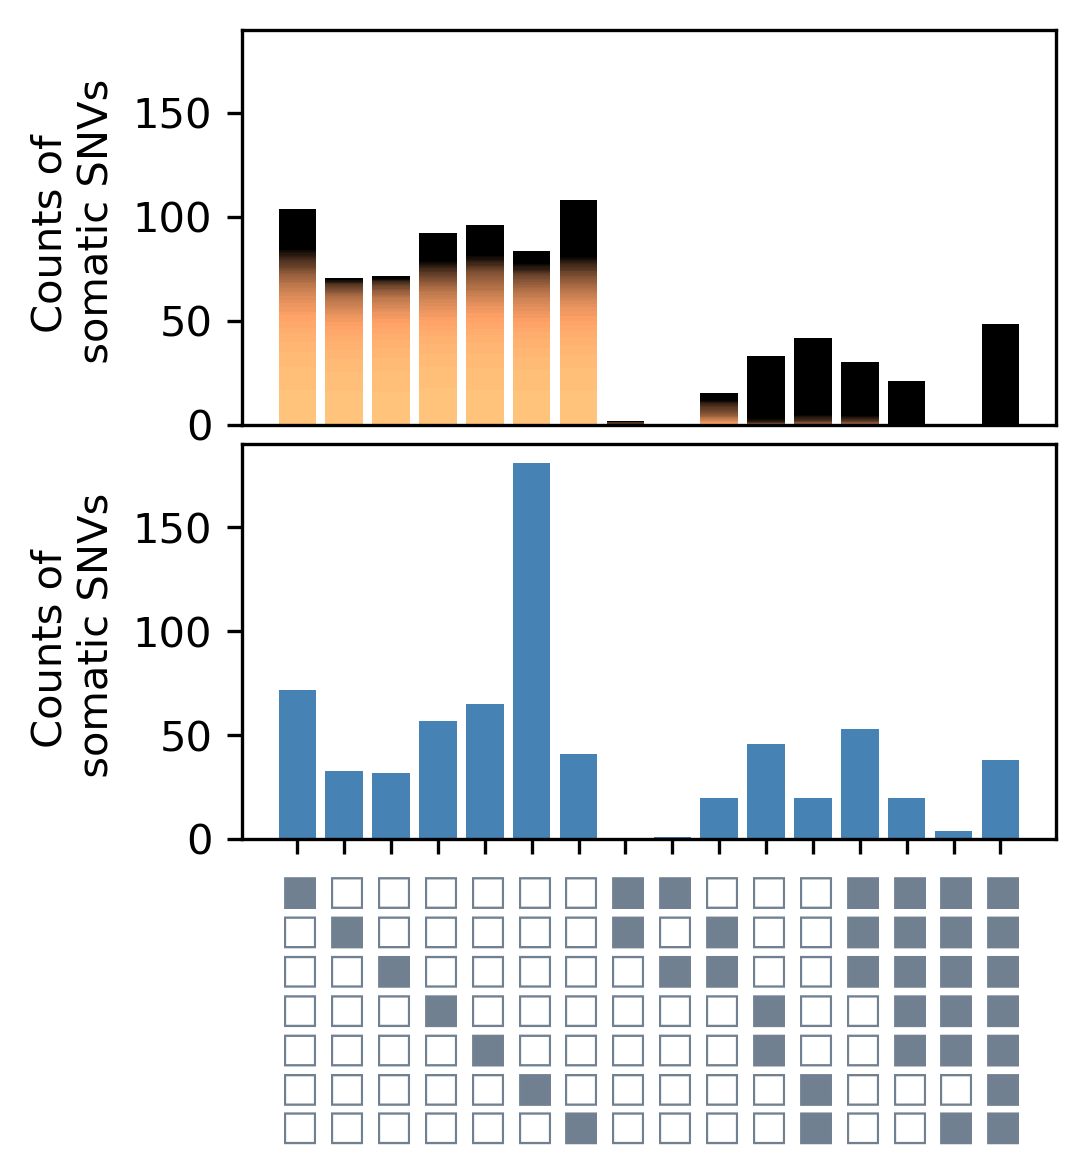

In [28]:
fig, ax = plt.subplots(2, 1, figsize=(3.50394, 3.50394), dpi=300)

# plotting simulation
plt.subplot(2, 1, 1)
for kcut,k in enumerate(predList):
    bottom_data = 0 #for plot
    for lcut,l in enumerate(k[1]):
        plt.bar(kcut,l,bottom=bottom_data,color=cm.copper(1-(lcut+1)/(NumStem*sum(k[0]))))
        
        bottom_data += l

# writing pattern on x_axis(xtrick)
plt.xticks([])
plt.ylabel('Counts of \n somatic SNVs', fontsize = 10)
plt.tick_params(axis='y', which='major', labelsize=10)
plt.ylim(0,ylim_dict[ind])
# plt.show()

#plotting data
plt.subplot(2, 1, 2)
for kcut,k in enumerate(dataList):    
    for l in range(numBranch+1):# to change color by bar graf 
        if sum(k[0])==l:
            plt.bar(kcut,k[1], color=colordict[ind]) # "darkorange", "sandybrown"
            
#writing pattern on x_axis(xtrick)
plt.xticks([i for i in range(len(dist_labels))], dist_labels, fontsize=10, rotation=90, color='slategrey') # 0811
plt.ylabel('Counts of \n somatic SNVs', fontsize = 10)
plt.tick_params(axis='y', which='major', labelsize=10)
plt.ylim(0,ylim_dict[ind])

plt.subplots_adjust(hspace=0.05)
plt.show()

In [40]:
#mutation at the tip of branches
def mut_hist_func(resultList_2):
    
    numBranch = np.array(resultList_2[0]).shape[0]
    mutShapeTemplate = np.array(list(itertools.product([0,1],repeat=numBranch))) #numpyであれば、計算できるが、repeat数が多くならないよう注意

    NumStemList = []

    #for Freq
    NummutFreqAtBranch = [] #mut freq at the end of branches
    NummutFreqAt_main_lateral = [] #mut freq at the end of branches
    Nummut_freqDifMatrix = [] #mutTimeFreq with Threshold
    NumsumSEmutFreqAtBranch = [] #for SE of sumMut
    NumsumSEmutFreqAt_main_lateral = [] #for SE of sumMut

    for NumStem in [paraL[1]]:
        NumTime = len(resultList_2)

        SummutFreqAtBranch = np.array([[0 for k in range(NumStem)] for i in range(numBranch)]) #for mutFreq
        totalmutFreqAtBranch = [] #for atBranch freq
        totalmutFreqAt_main_lateral = [] #for main - lateral

        for num_time in range(NumTime):

            br_brmutMatrix = resultList_2[num_time]
            
            #Freq of mutation dependent analysis
            #変異のメリステム内の頻度によって、検出の閾値をもうける
            br_brmut_freqMatrix = [] #閾値を変化させたときの 変異行列の変化 br_brmutMatrix, (0,0,...,0)の行は除いていない

            for k in range(NumStem): # k is threshold of mut_freq
                pre_freqMatrix = [[0 for i in br_brmutMatrix[0]] for i in br_brmutMatrix]
                for icut,i in enumerate(br_brmutMatrix):
                    for j in range(len(br_brmutMatrix[0])):
                        if i[j]<= k: # k以下の細胞数の変異を除く
                            pre_freqMatrix[icut][j] = 0
                        else: # k以上の細胞数の変異
                            pre_freqMatrix[icut][j] = i[j]

                br_brmut_freqMatrix.append(pre_freqMatrix)

            br_brmut_freqMatrix = np.array(br_brmut_freqMatrix) # correspond to br_brmutMatrix for each thresholds

            #freq of mutations in meristems
            #at the end of branches
            mutFreqAtBranch = [[] for i in range(numBranch)] #11,12,13,14,41,42,43,44

            for lcut, l in enumerate(br_brmutMatrix):
                for k in range(1,NumStem+1):
                    mutFreqAtBranch[lcut].append(np.count_nonzero(l==k)) # count mutations whoese freq is k/NumStem       
            mutFreqAtBranch = np.array(mutFreqAtBranch) #0926

            SummutFreqAtBranch = SummutFreqAtBranch + mutFreqAtBranch   
            totalmutFreqAtBranch.append(mutFreqAtBranch) #for barplot

        #Ave related to freq
        AvemutFreqAtBranch = SummutFreqAtBranch/NumTime #[[1/NumStem,...,k/NumStem,...,1],...] #11,12,13,14,41,42,43,44
        NummutFreqAtBranch.append(AvemutFreqAtBranch)

        sumtotalmutFreqAtBranch = np.array([float(0) for k in range(numBranch)])
        for k in totalmutFreqAtBranch:
            sumtotalmutFreqAtBranch += (np.sum(k,axis=1)-np.sum(AvemutFreqAtBranch,axis=1))**2 #branchごと

        #main-lateral
        AvemutFreqAt_main_lateral = np.mean(totalmutFreqAt_main_lateral, axis=0)
        NummutFreqAt_main_lateral.append(AvemutFreqAt_main_lateral)
        sumtotalmutFreqAt_main_lateral = np.array([float(0) for k in range(2)])
        for k in totalmutFreqAt_main_lateral: #for main-lateral
            sumtotalmutFreqAt_main_lateral += (np.sum(k,axis=1)-np.sum(AvemutFreqAt_main_lateral,axis=1))**2 #branchごと

        NumsumSEmutFreqAtBranch.append((sumtotalmutFreqAtBranch/len(totalmutFreqAtBranch))**(1/2)) #standered error for each branches
        NumsumSEmutFreqAt_main_lateral.append((sumtotalmutFreqAt_main_lateral/len(totalmutFreqAt_main_lateral))**(1/2))

        NumStemList.append(NumStem)
        
    return NummutFreqAtBranch, NumsumSEmutFreqAtBranch, NummutFreqAt_main_lateral, NumsumSEmutFreqAt_main_lateral

In [41]:
NummutFreqAtBranch, NumsumSEmutFreqAtBranch, NummutFreqAt_main_lateral, NumsumSEmutFreqAt_main_lateral = mut_hist_func(test_matrix2)

/var/folders/h6/2y96bpx17_v5f29y2w1pkh2w0000gn/T/ipykernel_15636/413315039.py:72: RuntimeWarning: invalid value encountered in divide
  NumsumSEmutFreqAt_main_lateral.append((sumtotalmutFreqAt_main_lateral/len(totalmutFreqAt_main_lateral))**(1/2))


In [42]:
ylim_dict2 = {'S1':260, 'S2':120, 'F1':60, 'F2':27}

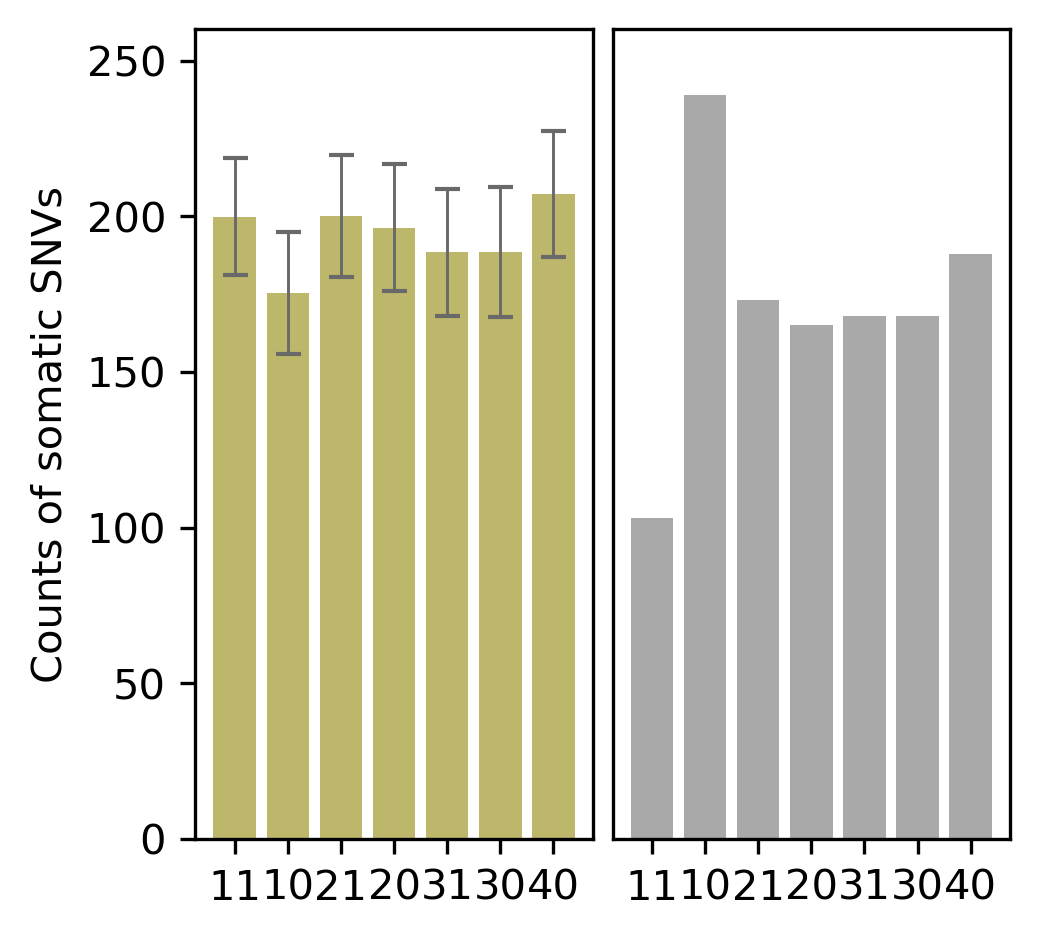

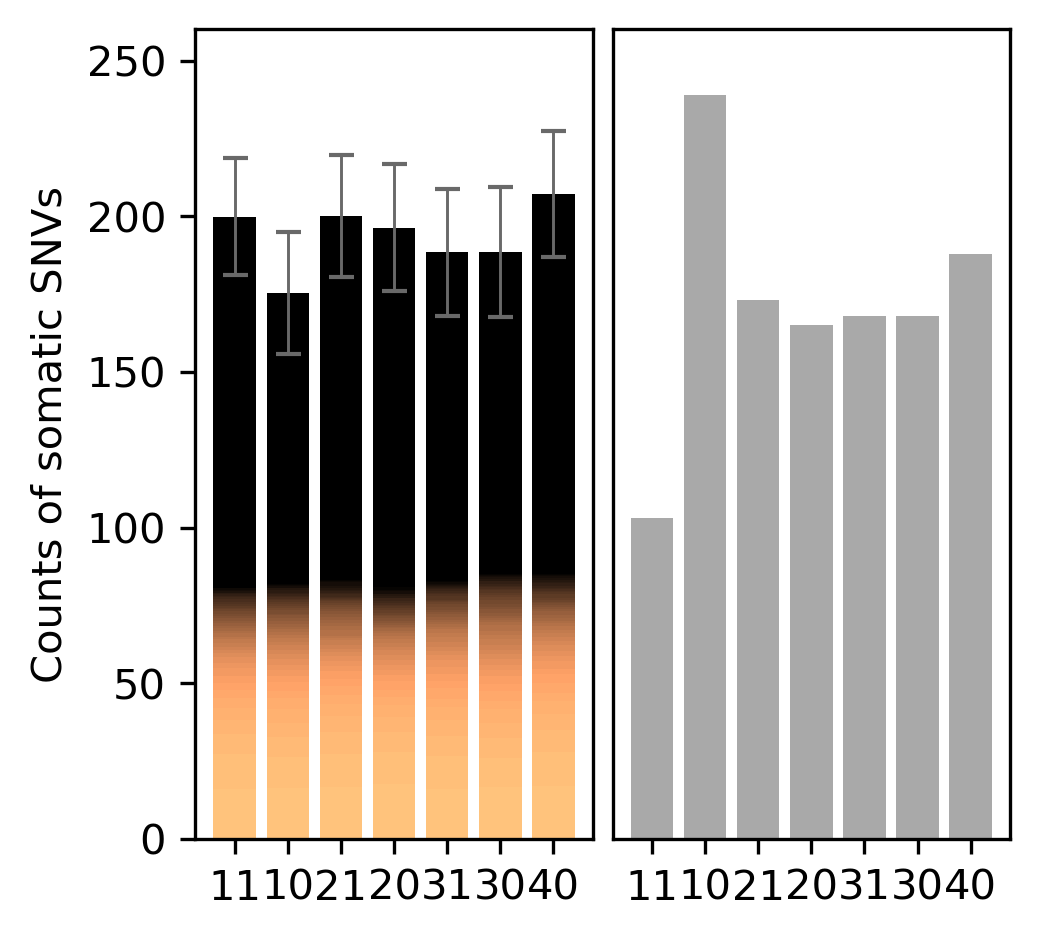

In [45]:
for lcut,l in enumerate(NummutFreqAtBranch):
    #plt.imshow(, cmap=cm.hot)
    #plt.set_cmap('hot')
    labeList = [str(k)+'/'+str(len(l[0])) for k in range(1,len(l[0])+1)] #len(l[0])=NumStem
    #labeList = [str(k)+' / α' for k in range(1,len(l[0])+1)] 

    #Number -----------------------------------------------------
    fig, ax = plt.subplots(1, 2, figsize=(3.50394, 3.50394), dpi=300)

    plt.subplot(1, 2, 1) # simulation ----
    bottom_data = np.zeros(numBranch)
    for kcut, k in enumerate(l.T):
        plt.bar([i for i in br_ID],k,bottom=bottom_data,color="darkkhaki") # brTime_mutDifList stackplot
        bottom_data += k
        
        if kcut+1 == len(l[0]):
            plt.errorbar([i for i in br_ID],bottom_data, yerr= NumsumSEmutFreqAtBranch[lcut], ecolor="dimgrey", elinewidth=0.7, capsize=3, linestyle="None")        
            
    plt.ylabel('Counts of somatic SNVs')
    plt.ylim(0,ylim_dict2[ind])
    plt.tick_params(axis='x', labelsize=10)
    
    plt.subplot(1, 2, 2) # data ----
    plt.bar(br_ID, [np.sum(i) for i in mut_M.T], color="darkgray")
    plt.tick_params(axis='x', labelsize=10)
    plt.yticks([])

    plt.ylim(0,ylim_dict2[ind])
    plt.subplots_adjust(wspace=0.05)
    plt.show()
    
    
    #Freq ---------------------------------------------------------
    plt.subplots(1, 2, figsize=(3.50394, 3.50394), dpi=300)
    
    plt.subplot(1, 2, 1)
    bottom_data = np.zeros(numBranch)
    for kcut, k in enumerate(l.T):
        plt.bar([i for i in br_ID],k,bottom=bottom_data,label=labeList[kcut],color=cm.copper(1-(kcut+1)/len(l[0]))) # brTime_mutDifList stackplot
        bottom_data += k
        
        if kcut+1 == len(l[0]):
            plt.errorbar([i for i in br_ID],bottom_data, yerr= NumsumSEmutFreqAtBranch[lcut], ecolor="dimgrey", elinewidth=0.7, capsize=3, linestyle="None")        
            
    plt.ylabel('Counts of somatic SNVs')
    plt.ylim(0,ylim_dict2[ind])
    plt.tick_params(axis='x', labelsize=10)
  
    plt.subplot(1, 2, 2) # data ----
    plt.bar(br_ID, [np.sum(i) for i in mut_M.T], color="darkgray")
    plt.tick_params(axis='x', labelsize=10)
    plt.yticks([])

    plt.ylim(0,ylim_dict2[ind])
    plt.subplots_adjust(wspace=0.05)
    plt.show()

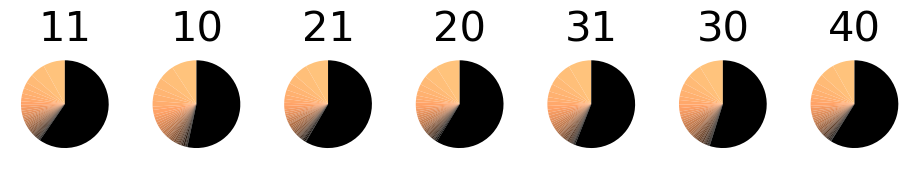

In [44]:
for lcut,l in enumerate(NummutFreqAtBranch):
    plt.figure(figsize=(15,5))
    
    for kcut, k in enumerate(l):
        plt.subplot(1,9,1+kcut)
        plt.pie(k, startangle=90, colors=[cm.copper(1-(i+1)/len(k)) for i in range(len(k))]) 
        plt.title(br_ID[kcut], fontsize=30)
    
    plt.show()

### Inter-branch genetic differences
2. frequency-dependent weighted detection (Average heterozygosity)

In [13]:
# Inter-branch mutations defined by average heterozygosity: frequency of mutated cells affects detection rate.

def ibm_dist_AveHet_func(resultList_2):
  
    numBranch = np.array(resultList_2[0]).shape[0]
    NumTime = len(resultList_2)
    
    Num_mut_dif_M = []

    for num_time in range(NumTime): # repeat of simulation

        br_brmutMatrix = resultList_2[num_time] # simulation results
        mut_dif_M = np.zeros(shape=(numBranch, numBranch)) # Distance matrix for inter-branch mutations

        for l in range(numBranch):
            for k in range(numBranch):
                
                if l!=k: # calculating non-diagonals
                    br_l = np.array(br_brmutMatrix[l])
                    br_k = np.array(br_brmutMatrix[k])
                    
                    ib_dif = (br_l/NumStem*(1-br_k/NumStem) + (1-br_l/NumStem)*br_k/NumStem) # Average heterozygosity
                    
                    mut_dif_M[l][k] = np.sum(ib_dif)

        Num_mut_dif_M.append(mut_dif_M)
        
    return Num_mut_dif_M # distance matrices for all simulations

In [14]:
Num_mut_ibms = ibm_dist_AveHet_func(test_matrix2)

<Figure size 700.788x630.709 with 0 Axes>

<Figure size 700.788x630.709 with 0 Axes>

<Figure size 700.788x630.709 with 0 Axes>

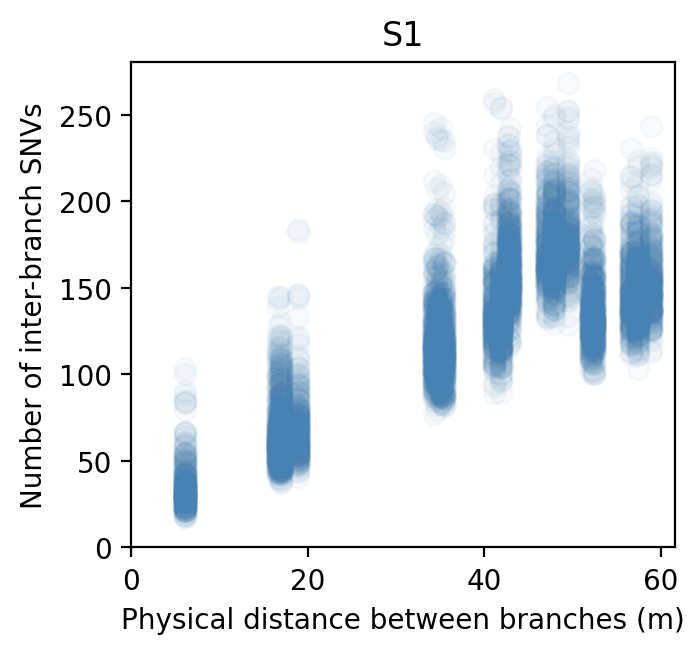

In [25]:
# Plotting
plt.figure(figsize=(3.50394, 0.9*3.50394), dpi=200) # 3.50394 inch = 89 mm (1 column)

# Flattening physical distance between branches
pre_mutCor_x = []
for i in range(numBranch):
    for j in range(numBranch):
        if i<j:
            pre_mutCor_x.append(brTimeMatrix[i][j]/div)

mutCor_x = np.array(pre_mutCor_x).flatten()

for ibm_m in Num_mut_ibms:
    numBranch = len(ibm_m) # number of branches
    
    # Flattening genetic distance between branches
    pre_mutCor_y = []
    for i in range(numBranch):
        for j in range(numBranch):
            if i<j:
                pre_mutCor_y.append(ibm_m[i][j]) 
                
    mutCor_y = np.array(pre_mutCor_y).flatten()
    
    plt.scatter(mutCor_x, mutCor_y, s=60, marker='o', alpha=1/30, c=colordict[ind])

plt.title(ind)
plt.xlabel('Physical distance between branches (m)')
plt.ylabel('Number of inter-branch SNVs')
plt.xlim(0,); plt.ylim(0,)
plt.show()

#### Comparison with Observations

In [26]:
# Data: inter-branch mutations, from Satake et al. 2023 eLife

mut_M_S1 = np.array( [[  0, 252, 220, 212, 216, 216, 236],
                      [252,   0, 363, 355, 359, 359, 379],
                      [220, 363,   0, 122, 234, 234, 254],
                      [212, 355, 122,   0, 226, 226, 246],
                      [216, 359, 234, 226,   0,  66, 124],
                      [216, 359, 234, 226,  66,   0, 126],
                      [236, 379, 254, 246, 124, 126,   0]] )/388801756/2

mut_M_S2 = np.array( [[ 0,  36,  76,  75,  62,  62,  67],
                      [36,   0,  76,  75,  62,  62,  67],
                      [76,  76,   0,  27,  74,  74,  79],
                      [75,  75,  27,   0,  73,  73,  78],
                      [62,  62,  74,  73,   0,  20,  57],
                      [62,  62,  74,  73,  20,   0,  57],
                      [67,  67,  79,  78,  57,  57,   0]] )/320739335/2

mut_M_F1 = np.array( [[ 0, 17, 32, 35, 31, 28, 29],
                      [17,  0, 34, 37, 33, 30, 31],
                      [32, 34,  0, 13, 31, 28, 29],
                      [35, 37, 13,  0, 34, 31, 32],
                      [31, 33, 31, 34,  0,  7, 20],
                      [28, 30, 28, 31,  7,  0, 17],
                      [29, 31, 29, 32, 20, 17,  0]] )/323729573/2

mut_M_F2 = np.array([ [ 0, 29, 24, 26, 28, 29, 34],
                      [29,  0, 13, 15, 17, 18, 23],
                      [24, 13,  0,  6, 12, 13, 18],
                      [26, 15,  6,  0, 14, 15, 20],
                      [28, 17, 12, 14,  0,  7, 18],
                      [29, 18, 13, 15,  7,  0, 19],
                      [34, 23, 18, 20, 18, 19,  0]])/263488812/2

mut_S1_Flat = []; mut_S2_Flat = []; mut_F1_Flat = []; mut_F2_Flat = []

for k in range(numBranch):
    for l in range(numBranch):
        
        if k < l:
            mut_S1_Flat.append(mut_M_S1[k][l])
            mut_S2_Flat.append(mut_M_S2[k][l])
            mut_F1_Flat.append(mut_M_F1[k][l])
            mut_F2_Flat.append(mut_M_F2[k][l])

mut_S1_Flat = np.array(mut_S1_Flat).flatten()
mut_S2_Flat = np.array(mut_S2_Flat).flatten()
mut_F1_Flat = np.array(mut_F1_Flat).flatten()
mut_F2_Flat = np.array(mut_F2_Flat).flatten()

In [27]:
if ind == 'S1':
    gen_size = 388801756
elif ind == 'S2':
    gen_size = 320739335
elif ind == 'F1':
    gen_size = 323729573
elif ind == 'F2':
    gen_size = 263488812

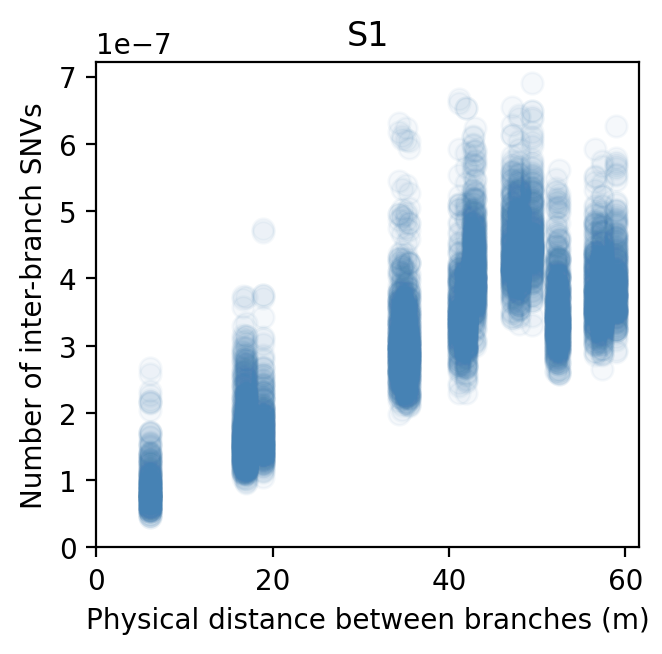

In [28]:
# Plotting
# Divided by genome size

plt.figure(figsize=(3.50394, 0.9*3.50394), dpi=200) # 3.50394 inch = 89 mm (1 column)

for ibm_m in Num_mut_ibms:
    numBranch = len(ibm_m) # number of branches
    
    # Flattening genetic distance between branches
    pre_mutCor_y = []
    for i in range(numBranch):
        for j in range(numBranch):
            if i<j:
                pre_mutCor_y.append(ibm_m[i][j]) 
                
    mutCor_y = np.array(pre_mutCor_y).flatten()/gen_size
    
    plt.scatter(mutCor_x, mutCor_y, s=60, marker='o', alpha=1/20, c=colordict[ind])

plt.title(ind)
plt.xlabel('Physical distance between branches (m)')
plt.ylabel('Number of inter-branch SNVs')
plt.xlim(0,); plt.ylim(0,)
plt.show()

### Comparing phylogenetic trees

In [29]:
import numpy as np
from scipy.cluster.hierarchy import linkage, to_tree
from scipy.spatial.distance import squareform
import dendropy
from dendropy.calculate import treecompare

In [32]:
# Comparing physical and genetic trees

Z_phys_dist = linkage(squareform(brTimeMatrix),  # physical distances between branches
                     method='average')  # UPGMA

# To Newick format ------------------------
def linkage_to_newick(Z, labels):
    tree = to_tree(Z)
    def build_newick(node):
        if node.is_leaf():
            return labels[node.id]
        else:
            left = build_newick(node.get_left())
            right = build_newick(node.get_right())
            return f"({left},{right})"
    return build_newick(tree) + ";"

# Constructing physical tree -------------
newick_phys = linkage_to_newick(Z_phys_dist, br_ID)  # br_ID gives labels of branches
tns = dendropy.TaxonNamespace(br_ID) # making common TaxonNamespace (needed to work well)

tree_phys = dendropy.Tree.get(
    data=newick_phys,
    schema="newick",
    taxon_namespace=tns
)

# Comparing with simulation results ------
same_topology_count = 0

for mut_ibms in Num_mut_ibms:

    mut_ibms = (mut_ibms + mut_ibms.T)/2 # diagonalize to meet linkage() requirements

    # tree construction by UPGMA
    Z_gen_dist = linkage(squareform(mut_ibms), method='average')
    newick_gen = linkage_to_newick(Z_gen_dist, br_ID)
    
    # making tree by dendropy
    tree_gen = dendropy.Tree.get(
        data=newick_gen,
        schema="newick",
        taxon_namespace=tns # the common TaxonNamespace
    )

    # Topology comparison by Robinson-Foulds distance
    rf = treecompare.unweighted_robinson_foulds_distance(tree_phys, tree_gen)
    if rf == 0: # topologies are identical
        same_topology_count += 1

match_ratio = same_topology_count / len(Num_mut_ibms)
print(f"Congruence count: {same_topology_count} / {len(Num_mut_ibms)}")
print(f"Congruence rate: {match_ratio:.3f}")

Congruence count: 219 / 250
Congruence rate: 0.876
